In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np

In [ ]:
df = pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [ ]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [ ]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


##### we can no colinearity with loan status

- there is a multicolinearity between person age and cred hist length which is justified

for the categorical values we have developed a formula for the target variable to check its score based on the target value,

In [ ]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [ ]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [ ]:
home_ownership_grouped = df.groupby(['person_home_ownership', 'loan_status']).size().unstack(fill_value=0)

home_ownership_grouped

loan_status,0,1
person_home_ownership,,
MORTGAGE,23341,1483
OTHER,74,15
OWN,3095,43
RENT,23785,6809


In [ ]:
reward_rate = 0.2

penalty_rate = 0.05

home_ownership_grouped['Score'] =  100 * np.log((home_ownership_grouped[1] + 1) / (home_ownership_grouped[0] + 1)) + reward_rate * home_ownership_grouped[1] - penalty_rate * home_ownership_grouped[0]

home_ownership_grouped

loan_status,0,1,Score
person_home_ownership,,,
MORTGAGE,23341,1483,-1146.001317
OTHER,74,15,-155.189939
OWN,3095,43,-571.517660
RENT,23785,6809,47.479495


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform((home_ownership_grouped['Score']).values.reshape(-1, 1))

scaled_data

home_ownership_grouped['scaled'] = scaled_data

In [ ]:
home_ownership_grouped

loan_status,0,1,Score,scaled
person_home_ownership,,,,
MORTGAGE,23341,1483,-1146.001317,-1.510962
OTHER,74,15,-155.189939,0.659679
OWN,3095,43,-571.517660,-0.252399
RENT,23785,6809,47.479495,1.103682


In [ ]:
def calculate_score(df, group_by_column, reward_rate=0.2, penalty_rate=0.05):



    # grouping by the dynamic column and loan status

    grouped = df.groupby([group_by_column, 'loan_status']).size().unstack(fill_value=0)

    grouped['Count'] = grouped[0] + grouped[1]



    grouped['Score'] = (

        100 * np.log((grouped[1] + 1) / (grouped[0] + 1)) +

        reward_rate * grouped[1] -

        penalty_rate * grouped[0]

    )

    scaler = StandardScaler()

    scaled_data = scaler.fit_transform((grouped['Score']).values.reshape(-1, 1))

    scaled_data

    grouped['scaled'] = scaled_data



    return grouped



result = calculate_score(df, 'person_home_ownership')

result


loan_status,0,1,Count,Score,scaled
person_home_ownership,,,,,
MORTGAGE,23341,1483,24824,-1146.001317,-1.510962
OTHER,74,15,89,-155.189939,0.659679
OWN,3095,43,3138,-571.517660,-0.252399
RENT,23785,6809,30594,47.479495,1.103682


here we can see that the situation is bit different from the reality , people getting better score when  they are  living on rent , as  opposed to they are livving on  their own and paying the money for their own home as mortgage



possible reasons

- skewed data

- possible that the mortgage havve a strict laws for rent than the rent loans which are small and and be greater in counts

okk lets check the feature importance, it will tell use if the feature is  just a random independent data or it will be a important variable in predictiong the target

In [ ]:
from scipy.stats import chi2_contingency



def chi_square_test(df, feature_column, target_column='loan_status'):



    contingency_table = pd.crosstab(df[feature_column], df[target_column])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    return chi2, p





chi2, p_value = chi_square_test(df, 'person_home_ownership')

print(f"Chi-Square Statistic: {chi2}, p-value: {p_value}")


Chi-Square Statistic: 3425.0639323497667, p-value: 0.0


since we get a high chi-square score and a lower p value, it  means the feature is not independent, and each category is conributing differently in target variable



p vvalue > 0.05 means the feature is statistically significant



There is a strong relationship between person_home_ownership and the likelihood of loan approval or rejection.

okk now lets test for loan_intent

In [ ]:
calculate_score(df, 'loan_intent').reset_index()

loan_status,loan_intent,0,1,Count,Score,scaled
0,DEBTCONSOLIDATION,7404,1729,9133,-169.803404,1.106143
1,EDUCATION,10949,1322,12271,-494.393757,-1.269477
2,HOMEIMPROVEMENT,5189,1091,6280,-197.122282,0.906201
3,MEDICAL,8985,1949,10934,-212.233844,0.795602
4,PERSONAL,8686,1330,10016,-355.889712,-0.255790
5,VENTURE,9082,929,10011,-496.197523,-1.282679


In [ ]:
chi2, p_value = chi_square_test = chi_square_test(df, 'loan_intent')

print(f"Chi-Square Statistic: {chi2}, p-value: {p_value}")


Chi-Square Statistic: 660.2262565994615, p-value: 1.9499337690925461e-140


chi-square ~= 660



p-value ~ 0



- there is a difference in those features categories spreading on 0's and 1's of target variable, the feature 'loan_intent' is not  a independent feature and each category influence the loan status in their own way



- p-value ~= 0 tells us that the feature is statistically significant

In [ ]:
calculate_score(df, 'loan_grade').reset_index()

loan_status,loan_grade,0,1,Count,Score,scaled
0,A,19952,1032,20984,-1087.291232,-1.725290
1,B,18313,2087,20400,-715.395912,-1.016839
2,C,9542,1494,11036,-363.668169,-0.346806
3,D,2046,2988,5034,533.156358,1.361623
4,E,378,631,1009,158.435319,0.647789
5,F,58,91,149,59.725113,0.459748
6,G,6,27,33,143.729436,0.619774


this data reult seems discrepant(illogical or surprising) the people with low loan score getting a good chance of getting the loan approved.



lets check the intent of the goal of those with grades as well

In [ ]:
grouped = df.groupby(['loan_grade', 'loan_status', 'loan_intent']).size().unstack(fill_value=0)

grouped_total = df.groupby(['loan_grade', 'loan_intent']).size().unstack(fill_value=0)

grouped_total.reset_index()


loan_intent,loan_grade,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,A,3384,4410,2143,3694,3695,3658
1,B,3089,4212,2060,3983,3485,3571
2,C,1678,2526,1190,2148,1727,1767
3,D,840,876,692,896,934,796
4,E,119,214,172,174,144,186
5,F,21,28,22,29,24,25
6,G,2,5,1,10,7,8


In [ ]:
df.groupby(['loan_grade', 'loan_status', 'loan_intent']).size().unstack(fill_value=0)

loan_intent             DEBTCONSOLIDATION  EDUCATION  HOMEIMPROVEMENT  \
loan_grade loan_status                                                  
A          0                         3200       4204             2019   
           1                          184        206              124   
B          0                         2732       3813             1785   
           1                          357        399              275   
C          0                         1416       2254              955   
           1                          262        272              235   
D          0                           52        557              334   
           1                          788        319              358   
E          0                            3        104               85   
           1                          116        110               87   
F          0                            1         17               10   
           1                           20         11               12   
G          0                            0          0                1   
           1                            2          5                0   

loan_intent             MEDICAL  PERSONAL  VENTURE  
loan_grade loan_status                              
A          0               3467      3506     3556  
           1                227       189      102  
B          0               3558      3068     3357  
           1                425       417      214  
C          0               1832      1503     1582  
           1                316       224      185  
D          0                116       514      473  
           1                780       420      323  
E          0                 11        79       96  
           1                163        65       90  
F          0                  1        13       16  
           1                 28        11        9  
G          0                  0         3        2  
           1                 10         4        6

In [ ]:
grouped_total = df.groupby(['loan_grade', 'loan_intent']).size().unstack(fill_value=0)

grouped_total

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
loan_grade,,,,,,
A,3384,4410,2143,3694,3695,3658
B,3089,4212,2060,3983,3485,3571
C,1678,2526,1190,2148,1727,1767
D,840,876,692,896,934,796
E,119,214,172,174,144,186
F,21,28,22,29,24,25
G,2,5,1,10,7,8


In [ ]:
df.iloc[:, 1:-1]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3
...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10
58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8
58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2
58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3


In [ ]:
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [ ]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [ ]:
df_numerical = df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']]

df_numerical

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
0,37,35000,0.0,6000,11.49,0.17,14,0
1,22,56000,6.0,4000,13.35,0.07,2,0
2,29,28800,8.0,6000,8.90,0.21,10,0
3,30,70000,14.0,12000,11.11,0.17,5,0
4,22,60000,2.0,6000,6.92,0.10,3,0
...,...,...,...,...,...,...,...,...
58640,34,120000,5.0,25000,15.95,0.21,10,0
58641,28,28800,0.0,10000,12.73,0.35,8,1
58642,23,44000,7.0,6800,16.00,0.15,2,1
58643,22,30000,2.0,5000,8.90,0.17,3,0


In [ ]:
X_train = df_numerical.iloc[:, 1:-1]

y_train = df_numerical['loan_status']

In [ ]:
import pandas as pd

from scipy.stats import pearsonr



pearson_results = {}



for feature in X_train.columns:

    corr, p_value = pearsonr(X_train[feature], y_train)

    pearson_results[feature] = {'Correlation': corr, 'P-value': p_value}



pearson_df = pd.DataFrame.from_dict(pearson_results, orient='index')



print(pearson_df)


                            Correlation        P-value
person_income                 -0.169956   0.000000e+00
person_emp_length             -0.100428  2.681954e-131
loan_amnt                      0.144982  6.794856e-273
loan_int_rate                  0.338948   0.000000e+00
loan_percent_income            0.378280   0.000000e+00
cb_person_cred_hist_length    -0.003030   4.630854e-01


In [ ]:
df_categorical = df[['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']]

In [ ]:
# chi_square_test_results = {}



# for feature in df_categorical.columns:

#     corr, p_value = chi_square_test(df_categorical, feature)

#     chi_square_test_results[feature] = {'Chi-Square': corr, 'P-value': p_value}



# chi_square_test_results = pd.DataFrame.from_dict(chi_square_test_results, orient='index')



# print(chi_square_test_results)

okk now we have seen the scores and feature selection scores, lets manage categorical and numerical features

In [ ]:
df['loan_status'].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

okk lets  select  all the important features based on scores and p-value

In [ ]:
df_selected = df[['loan_int_rate', 'loan_percent_income', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']]

In [ ]:
df_selected_encoded = pd.get_dummies(df, columns=['person_home_ownership'], drop_first=True)

df_selected_encoded = pd.get_dummies(df_selected_encoded, columns=['loan_intent'], drop_first=True)

df_selected_encoded = pd.get_dummies(df_selected_encoded, columns=['cb_person_default_on_file'], drop_first=True)

In [ ]:
df_selected_encoded

,id,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,0,37,35000,0.0,B,6000,11.49,0.17,14,0,False,False,True,True,False,False,False,False,False
1,1,22,56000,6.0,C,4000,13.35,0.07,2,0,False,True,False,False,False,True,False,False,False
2,2,29,28800,8.0,A,6000,8.90,0.21,10,0,False,True,False,False,False,False,True,False,False
3,3,30,70000,14.0,B,12000,11.11,0.17,5,0,False,False,True,False,False,False,False,True,False
4,4,22,60000,2.0,A,6000,6.92,0.10,3,0,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,5.0,D,25000,15.95,0.21,10,0,False,False,False,True,False,False,False,False,True
58641,58641,28,28800,0.0,C,10000,12.73,0.35,8,1,False,False,True,False,False,True,False,False,False
58642,58642,23,44000,7.0,D,6800,16.00,0.15,2,1,False,False,True,True,False,False,False,False,False
58643,58643,22,30000,2.0,A,5000,8.90,0.17,3,0,False,False,True,True,False,False,False,False,False


doing encoding for ordinal

In [ ]:
from sklearn.preprocessing import OrdinalEncoder



ordinal_encoder = OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']])

df_selected_encoded['loan_grade_encoded'] = ordinal_encoder.fit_transform(df_selected_encoded[['loan_grade']])


In [ ]:
df_selected_encoded

,id,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
0,0,37,35000,0.0,B,6000,11.49,0.17,14,0,False,False,True,True,False,False,False,False,False,1.0
1,1,22,56000,6.0,C,4000,13.35,0.07,2,0,False,True,False,False,False,True,False,False,False,2.0
2,2,29,28800,8.0,A,6000,8.90,0.21,10,0,False,True,False,False,False,False,True,False,False,0.0
3,3,30,70000,14.0,B,12000,11.11,0.17,5,0,False,False,True,False,False,False,False,True,False,1.0
4,4,22,60000,2.0,A,6000,6.92,0.10,3,0,False,False,True,False,False,True,False,False,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,5.0,D,25000,15.95,0.21,10,0,False,False,False,True,False,False,False,False,True,3.0
58641,58641,28,28800,0.0,C,10000,12.73,0.35,8,1,False,False,True,False,False,True,False,False,False,2.0
58642,58642,23,44000,7.0,D,6800,16.00,0.15,2,1,False,False,True,True,False,False,False,False,False,3.0
58643,58643,22,30000,2.0,A,5000,8.90,0.17,3,0,False,False,True,True,False,False,False,False,False,0.0


In [ ]:
df_selected_encoded = df_selected_encoded.drop(columns=['loan_grade'])

now we will scale the numerical columns

In [ ]:
from sklearn.preprocessing import StandardScaler



numerical_data = df_selected_encoded[['loan_amnt', 'person_income']]



scaler = StandardScaler()

scaled_numerical = pd.DataFrame(scaler.fit_transform(numerical_data), columns=['loan_amnt', 'person_income'])



df_scaled = df_selected_encoded.drop(columns=['loan_amnt', 'person_income'])



df_final = pd.concat([df_scaled, scaled_numerical], axis=1)

df_final


,id,person_age,person_emp_length,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded,loan_amnt,person_income
0,0,37,0.0,11.49,0.17,14,0,False,False,True,True,False,False,False,False,False,1.0,-0.578306,-0.765768
1,1,22,6.0,13.35,0.07,2,0,False,True,False,False,False,True,False,False,False,2.0,-0.937775,-0.212128
2,2,29,8.0,8.90,0.21,10,0,False,True,False,False,False,False,True,False,False,0.0,-0.578306,-0.929223
3,3,30,14.0,11.11,0.17,5,0,False,False,True,False,False,False,False,True,False,1.0,0.500101,0.156966
4,4,22,2.0,6.92,0.10,3,0,False,False,True,False,False,True,False,False,False,0.0,-0.578306,-0.106673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,5.0,15.95,0.21,10,0,False,False,False,True,False,False,False,False,True,3.0,2.836651,1.475156
58641,58641,28,0.0,12.73,0.35,8,1,False,False,True,False,False,True,False,False,False,2.0,0.140632,-0.929223
58642,58642,23,7.0,16.00,0.15,2,1,False,False,True,True,False,False,False,False,False,3.0,-0.434518,-0.528494
58643,58643,22,2.0,8.90,0.17,3,0,False,False,True,True,False,False,False,False,False,0.0,-0.758041,-0.897587


now  lets do a logistic regression

In [ ]:
from sklearn.model_selection import train_test_split



X = df_selected_encoded.drop(columns=['loan_status'])

y = df_selected_encoded['loan_status']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression



LR = LogisticRegression()

LR.fit(X_train, y_train)


LogisticRegression()

In [ ]:
LR.score(X_test, y_test)

0.8876289538750106

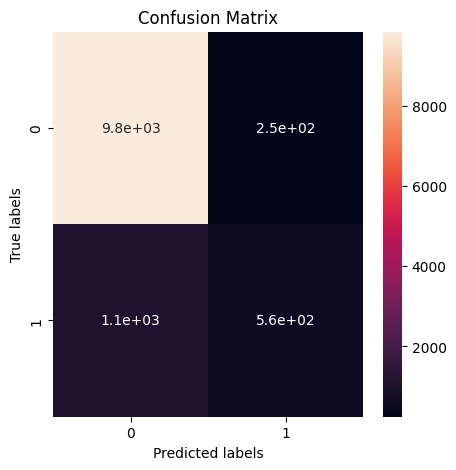

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score

y_pred_LR=LR.predict(X_test)



plt.rcParams['figure.figsize']=5,5

ax= plt.subplot()

cm = confusion_matrix(y_test, y_pred_LR)

sns.heatmap(cm, annot=True, ax = ax);



# labels, title and ticks

ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');

ax.set_title('Confusion Matrix');

ax.xaxis.set_ticklabels(['0', '1']); ax.yaxis.set_ticklabels(['0', '1']);


In [ ]:
fpr, tpr, thres = roc_curve(y_test, LR.predict_proba(X_test)[:,1])

roc_auc = auc(fpr, tpr)

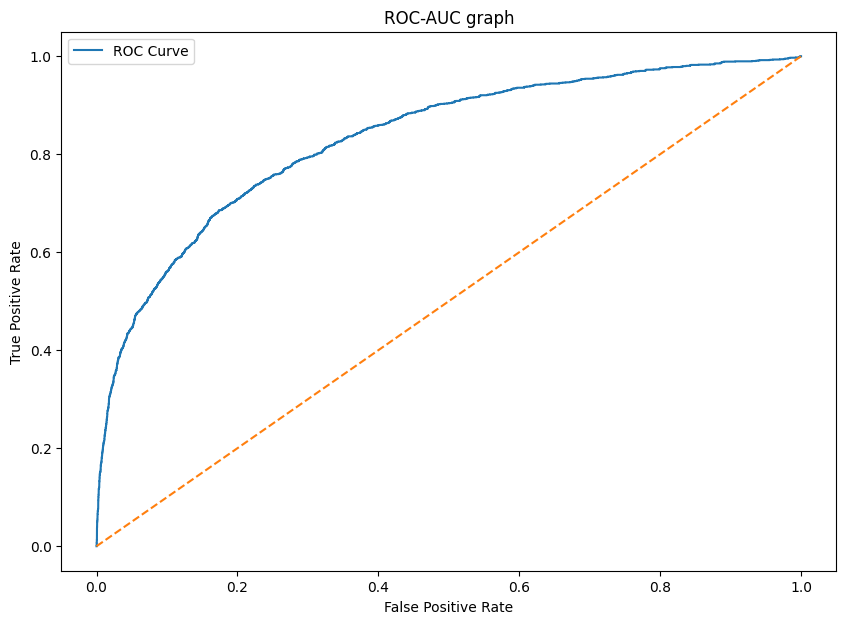

In [ ]:
plt.rcParams['figure.figsize']=10,7

plt.plot(fpr, tpr, label = 'ROC Curve' %roc_auc)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.title('ROC-AUC graph')

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()

RF.fit(X_train, y_train)



RF.score(X_test, y_test)

0.9500383664421519

In [ ]:


roc_auc_score(y_test, RF.predict_proba(X_test)[:,1])

0.9356578257181759

now lets train it on xgb

In [ ]:
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score



X_train_part, X_val, y_train_part, y_val = train_test_split(

    X_train, y_train, test_size=0.2, random_state=42

)



xgb_params = {

    'eval_metric': 'auc',

    'n_estimators': 5000,

    'learning_rate': 0.11,

    'max_depth': 8,

    'subsample': 1.0,

    'colsample_bytree': 0.4968,

    'reg_alpha': 8.92e-06,

    'reg_lambda': 10.0,

    'gamma': 0.0979,

    'min_child_weight': 1.0,

    'max_bin': 262143,

    'early_stopping_rounds': 100,

    'use_label_encoder': False,

}



xgb_model = XGBClassifier(**xgb_params)



xgb_model.fit(

    X_train_part, y_train_part,

    eval_set=[(X_val, y_val)],

    verbose=100

)



y_train_pred = xgb_model.predict(X_train)



train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")


[0]	validation_0-auc:0.82501
[100]	validation_0-auc:0.95938
[200]	validation_0-auc:0.96198
[300]	validation_0-auc:0.96211
[383]	validation_0-auc:0.96168
Training Accuracy: 0.9660


In [ ]:
X_train_part.head()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
14721,14721,23,35004,0.0,5000,8.49,0.14,3,False,False,True,False,False,False,True,False,False,0.0
11559,11559,25,75000,5.0,13000,10.62,0.17,3,False,False,False,False,False,False,True,False,False,1.0
4003,4003,23,58000,7.0,7500,7.51,0.13,2,False,False,False,False,False,False,True,False,False,0.0
27203,27203,25,100000,1.0,7000,6.76,0.07,3,False,False,False,False,True,False,False,False,False,0.0
47358,47358,36,40000,1.0,3000,11.49,0.07,13,False,True,False,False,False,False,False,True,False,1.0


In [ ]:
accuracy_score(y_test, xgb_model.predict(X_test))

0.951828800409242

In [ ]:
roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

0.955524697138942

In [ ]:
sample = pd.read_csv('/kaggle/input/playground-series-s4e10/sample_submission.csv')

In [ ]:
sample

,id,loan_status
0,58645,0.5
1,58646,0.5
2,58647,0.5
3,58648,0.5
4,58649,0.5
...,...,...
39093,97738,0.5
39094,97739,0.5
39095,97740,0.5
39096,97741,0.5


okk now we take full train and test

In [ ]:
train = pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s4e10/test.csv')

In [ ]:
train_selected = train[['loan_int_rate', 'loan_percent_income', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_status']]
test_selected = test[['loan_int_rate', 'loan_percent_income', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']]

In [ ]:
train_selected_encoded = pd.get_dummies(train, columns=['person_home_ownership'], drop_first=True)
train_selected_encoded = pd.get_dummies(train_selected_encoded, columns=['loan_intent'], drop_first=True)
train_selected_encoded = pd.get_dummies(train_selected_encoded, columns=['cb_person_default_on_file'], drop_first=True)

test_selected_encoded = pd.get_dummies(test, columns=['person_home_ownership'], drop_first=True)
test_selected_encoded = pd.get_dummies(test_selected_encoded, columns=['loan_intent'], drop_first=True)
test_selected_encoded = pd.get_dummies(test_selected_encoded, columns=['cb_person_default_on_file'], drop_first=True)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder



ordinal_encoder = OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']])

train_selected_encoded['loan_grade_encoded'] = ordinal_encoder.fit_transform(train_selected_encoded[['loan_grade']])
test_selected_encoded['loan_grade_encoded'] = ordinal_encoder.transform(test_selected_encoded[['loan_grade']])

In [ ]:
train_selected_encoded.head()

,id,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
0,0,37,35000,0.0,B,6000,11.49,0.17,14,0,False,False,True,True,False,False,False,False,False,1.0
1,1,22,56000,6.0,C,4000,13.35,0.07,2,0,False,True,False,False,False,True,False,False,False,2.0
2,2,29,28800,8.0,A,6000,8.90,0.21,10,0,False,True,False,False,False,False,True,False,False,0.0
3,3,30,70000,14.0,B,12000,11.11,0.17,5,0,False,False,True,False,False,False,False,True,False,1.0
4,4,22,60000,2.0,A,6000,6.92,0.10,3,0,False,False,True,False,False,True,False,False,False,0.0


In [ ]:
train_selected_encoded.head()

,id,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
0,0,37,35000,0.0,B,6000,11.49,0.17,14,0,False,False,True,True,False,False,False,False,False,1.0
1,1,22,56000,6.0,C,4000,13.35,0.07,2,0,False,True,False,False,False,True,False,False,False,2.0
2,2,29,28800,8.0,A,6000,8.90,0.21,10,0,False,True,False,False,False,False,True,False,False,0.0
3,3,30,70000,14.0,B,12000,11.11,0.17,5,0,False,False,True,False,False,False,False,True,False,1.0
4,4,22,60000,2.0,A,6000,6.92,0.10,3,0,False,False,True,False,False,True,False,False,False,0.0


In [ ]:
train_selected_encoded = train_selected_encoded.drop(columns=['loan_grade'], errors='ignore')
test_selected_encoded = test_selected_encoded.drop(columns=['loan_grade'], errors='ignore')

In [ ]:
train_y = pd.DataFrame(train_selected_encoded['loan_status'])
train_X = train_selected_encoded.drop(columns=['loan_status'], errors='ignore')

test_X = test_selected_encoded.drop(columns=['loan_status'], errors='ignore')

In [ ]:
test_X.shape

(39098, 18)

In [ ]:
train_X.head()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
0,0,37,35000,0.0,6000,11.49,0.17,14,False,False,True,True,False,False,False,False,False,1.0
1,1,22,56000,6.0,4000,13.35,0.07,2,False,True,False,False,False,True,False,False,False,2.0
2,2,29,28800,8.0,6000,8.90,0.21,10,False,True,False,False,False,False,True,False,False,0.0
3,3,30,70000,14.0,12000,11.11,0.17,5,False,False,True,False,False,False,False,True,False,1.0
4,4,22,60000,2.0,6000,6.92,0.10,3,False,False,True,False,False,True,False,False,False,0.0


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

xgb_params = {
    'eval_metric': 'auc',
    'n_estimators': 5000,
    'learning_rate': 0.11,
    'max_depth': 8,
    'subsample': 1.0,
    'colsample_bytree': 0.4968,
    'reg_alpha': 8.92e-06,
    'reg_lambda': 10.0,
    'gamma': 0.0979,
    'min_child_weight': 1.0,
    'max_bin': 262143,

    'use_label_encoder': False,
}



xgb_model = XGBClassifier(**xgb_params)



xgb_model.fit(train_X, train_y, verbose=100)



y_train_pred = xgb_model.predict(train_X)



print(y_train_pred)

[0 0 0 ... 1 0 0]


In [ ]:
loan_status_predictions = xgb_model.predict_proba(test_X)[:, 1]

In [ ]:
loan_status_predictions.shape

(39098,)

In [ ]:
loan_status_predictions = loan_status_predictions.ravel()

submission_df = pd.DataFrame({
    'id': test['id'],
    'loan_status': loan_status_predictions
})


In [ ]:
submission_df

,id,loan_status
0,58645,0.999337
1,58646,0.017154
2,58647,0.744931
3,58648,0.006618
4,58649,0.097540
...,...,...
39093,97738,0.038690
39094,97739,0.003825
39095,97740,0.028690
39096,97741,0.601172


In [ ]:
submission_df.to_csv('submission.csv', index=False)